# E-commerce Sales Analysis

This project explores an e-commerce dataset to uncover key business insights using SQL and Python.

The analysis focuses on revenue trends, customer behavior, and product performance.

## Objectives

- Analyze revenue distribution across countries
- Identify top-performing products
- Understand monthly revenue trends
- Identify high-value customers

## Dataset Overview

The dataset contains over 500,000 transaction records, including:

- Product descriptions
- Transaction dates
- Customer IDs
- Countries
- Quantity and unit price

Each row represents a transaction.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

## Load Dataset

In [2]:
df = pd.read_csv("../data/online_retail.csv")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Data Cleaning and Preparation

In this step, we:

- Convert date columns to datetime format
- Convert numeric columns
- Create a revenue column

In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Feature Engineering

We create a new column to extract the transaction month for time-based analysis.

In [8]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [9]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


## Revenue by Country

This analysis shows which countries generate the most revenue, helping identify key markets.

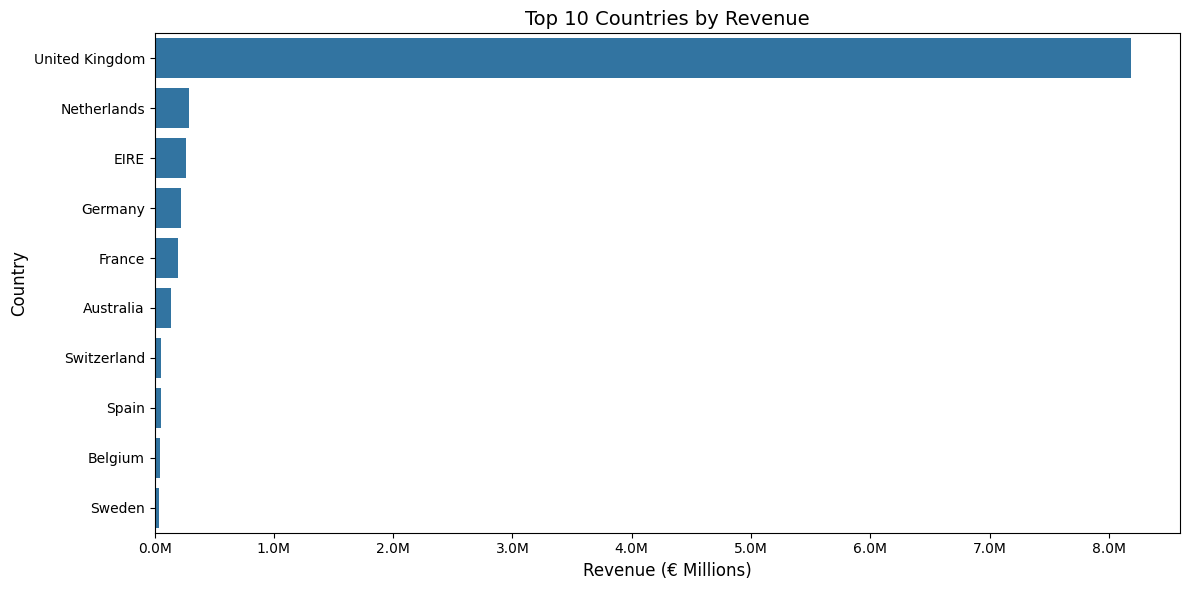

In [15]:
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=country_revenue.values,
    y=country_revenue.index
)

plt.title("Top 10 Countries by Revenue", fontsize=14)
plt.xlabel("Revenue (€ Millions)", fontsize=12)
plt.ylabel("Country", fontsize=12)

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

plt.tight_layout()

plt.savefig("../outputs/revenue_by_country.png", dpi=300)

plt.show()

## Top Products

This analysis identifies the products generating the highest revenue.

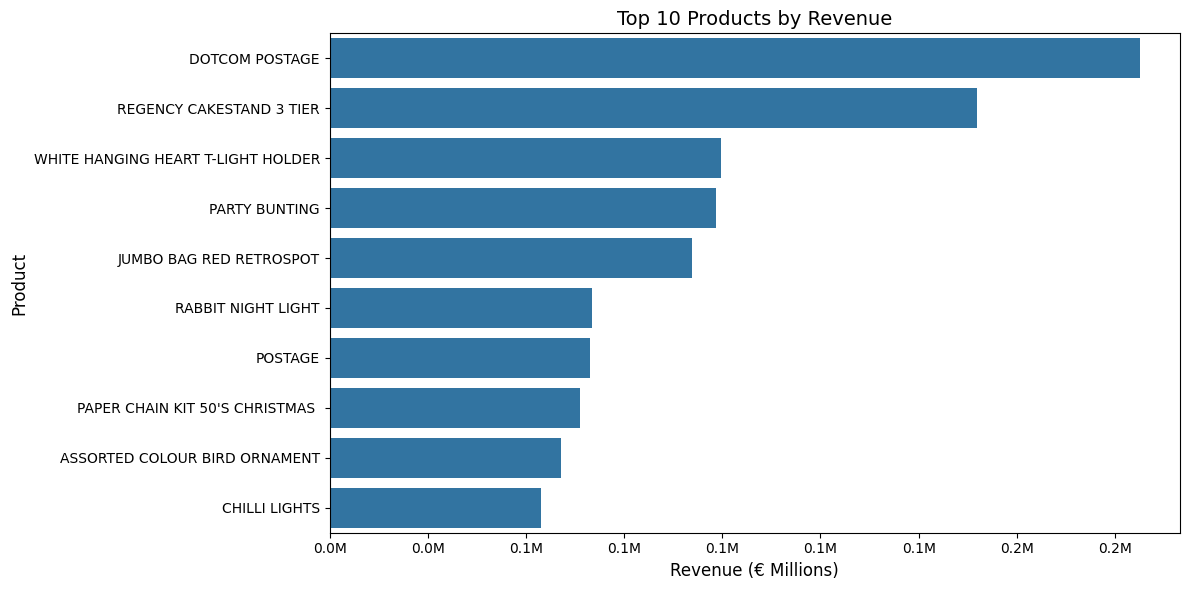

In [17]:
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Revenue", fontsize=14)
plt.xlabel("Revenue (€ Millions)", fontsize=12)
plt.ylabel("Product", fontsize=12)

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

plt.tight_layout()

plt.savefig("../outputs/top_products.png", dpi=300)

plt.show()

## Monthly Revenue Analysis

We aggregate revenue by month to understand how sales evolve over time.

In [10]:
monthly_revenue = df.groupby("Month")["Revenue"].sum().reset_index()

In [11]:
monthly_revenue.head()

,Month,Revenue
0,2010-12,748957.020
1,2011-01,560000.260
2,2011-02,498062.650
3,2011-03,683267.080
4,2011-04,493207.121


In [12]:
monthly_revenue["Month"] = monthly_revenue["Month"].astype(str)

## Visualization

The chart below shows the monthly revenue trend, highlighting seasonal patterns and growth periods.

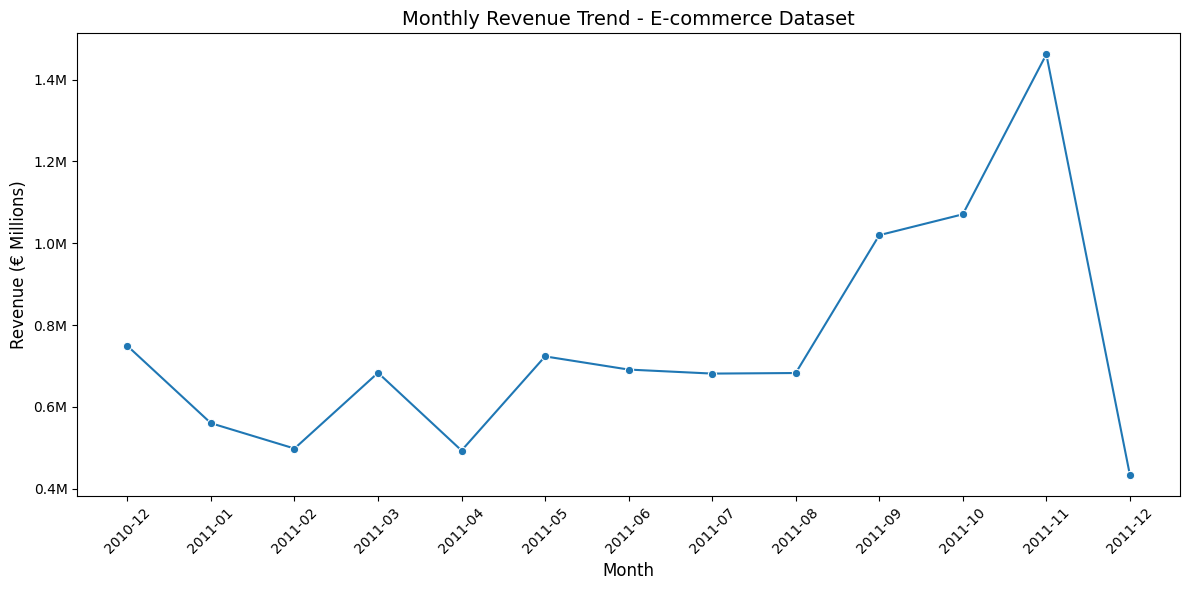

In [14]:
plt.figure(figsize=(12,6))

ax = sns.lineplot(
    data=monthly_revenue,
    x="Month",
    y="Revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend - E-commerce Dataset", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue (€ Millions)", fontsize=12)

plt.xticks(rotation=45)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

plt.tight_layout()

plt.savefig("../outputs/monthly_revenue_trend.png", dpi=300)

plt.show()

## Top Customers

This analysis highlights the customers who generate the most revenue.

## Key Insights

- Revenue shows strong growth in the final months of the year
- There is clear seasonality in sales patterns
- A peak occurs around November, likely due to holiday demand

These insights can support business decisions related to inventory, marketing, and customer targeting.